<a href="https://colab.research.google.com/github/martincastanonicolas-source/AI/blob/master/Proyecto/Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)

# ── Carga del dataset ─────────────────────────────────────────────────────────
# ';' como separador y ',' como decimal (estándar Agencia Tributaria)
df = pd.read_csv('modelo200.csv', sep=';', decimal=',')
df = df[df['EJER'] < 2023].copy()

SECTOR_MAP = {1:'Agricultura', 2:'Extractiva', 3:'Industria', 4:'Construcción',
              5:'Comercio', 6:'Info/TIC', 7:'Financieras', 8:'Serv.Empresa',
              9:'Serv.Sociales', 10:'Otros'}

CCAA_MAP = {1:'Andalucía', 2:'Aragón', 3:'Asturias', 4:'Baleares', 5:'Canarias',
            6:'Cantabria', 7:'Cast.León', 8:'Cast.Mancha', 9:'Cataluña',
            10:'C.Valenciana', 11:'Extremadura', 12:'Galicia', 13:'Madrid',
            14:'Murcia', 17:'La Rioja', 77:'Resto'}

df['SECTOR_NM'] = df['SECTOR'].map(SECTOR_MAP)
df['CCAA_NM'] = df['CCAA'].map(CCAA_MAP)
df['RC_NM'] = df['RC'].map({1:'RC ≤ 0 (pérdidas)', 2:'RC > 0 (beneficios)'})
df['DIM_NM'] = df['DIM'].map({0:'Resto empresas', 1:'Reducida dimensión'})
df['log_target'] = np.log1p(df['M200_33'])

TARGET = 'M200_33'

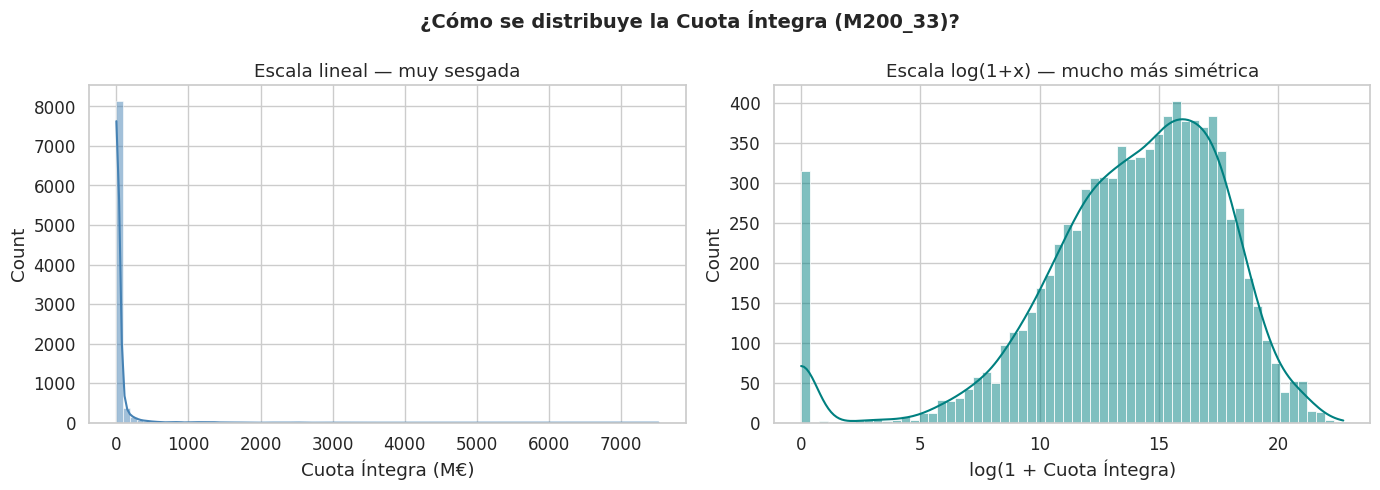

In [61]:
# ══════════════════════════════════════════════════════════════════
# FIG 1 — ¿Cómo es el target? Escala lineal vs log
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('¿Cómo se distribuye la Cuota Íntegra (M200_33)?', fontsize=14, fontweight='bold')

sns.histplot(df[TARGET] / 1e6, bins=80, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Escala lineal — muy sesgada')
axes[0].set_xlabel('Cuota Íntegra (M€)')

sns.histplot(df['log_target'], bins=60, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Escala log(1+x) — mucho más simétrica')
axes[1].set_xlabel('log(1 + Cuota Íntegra)')

plt.tight_layout()
plt.show()

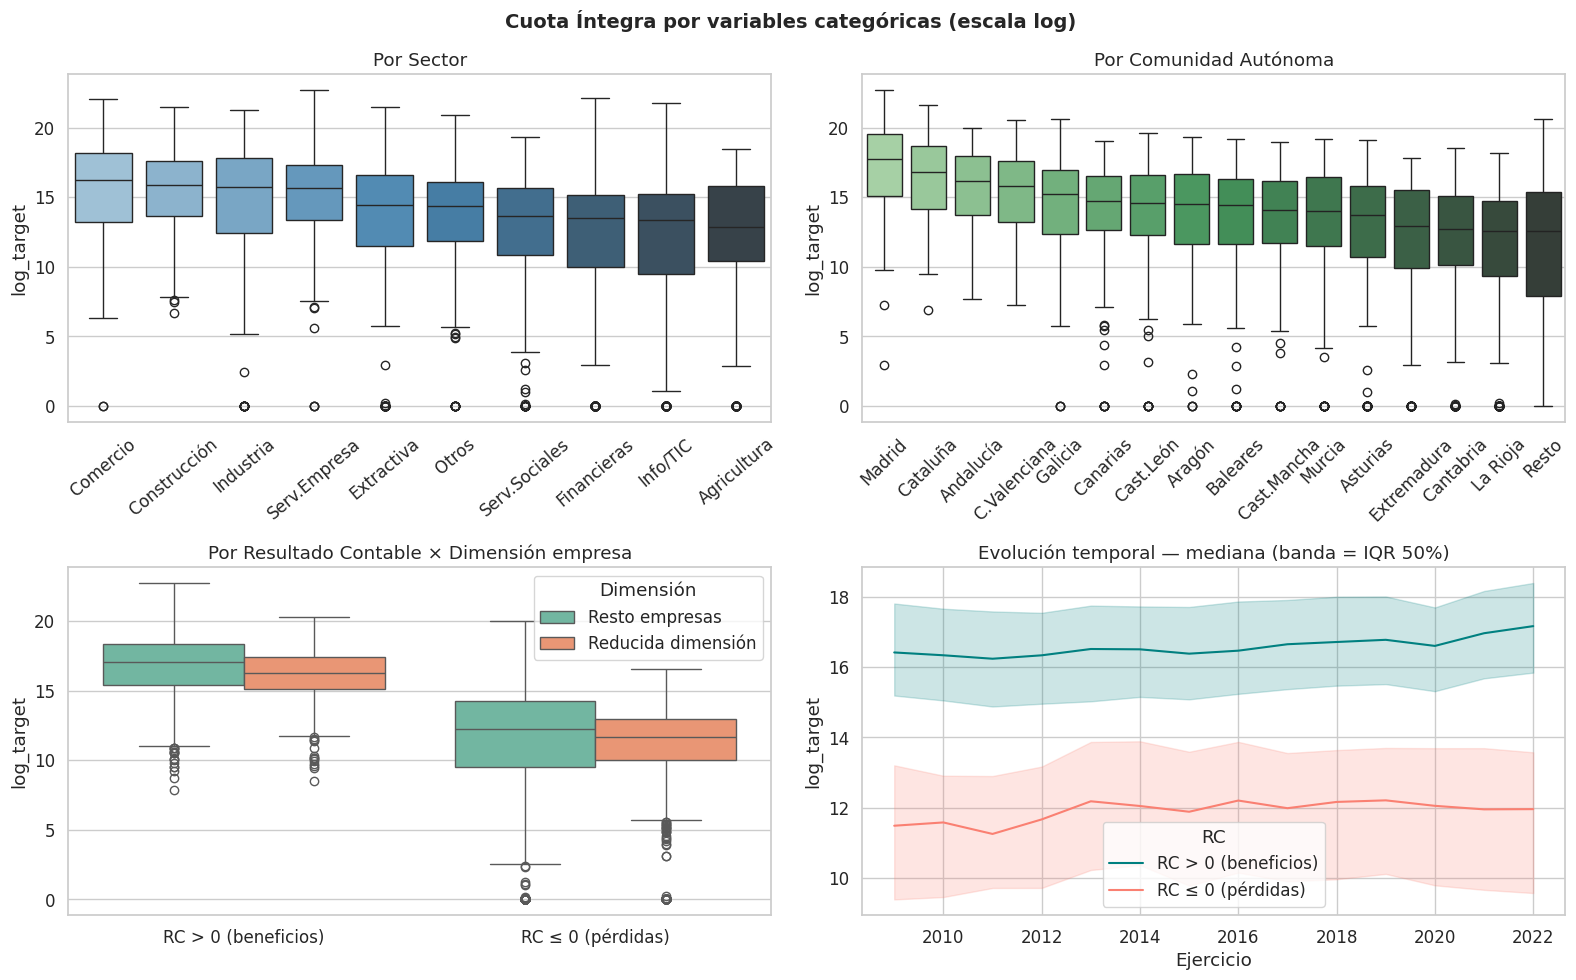

In [62]:
# ══════════════════════════════════════════════════════════════════
# FIG 2 — Target por las categóricas principales
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Cuota Íntegra por variables categóricas (escala log)', fontsize=14, fontweight='bold')

order_sector = df.groupby('SECTOR_NM')['log_target'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='SECTOR_NM', y='log_target', order=order_sector,
            palette='Blues_d', ax=axes[0, 0])
axes[0, 0].set_title('Por Sector')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=40)

order_ccaa = df.groupby('CCAA_NM')['log_target'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='CCAA_NM', y='log_target', order=order_ccaa,
            palette='Greens_d', ax=axes[0, 1])
axes[0, 1].set_title('Por Comunidad Autónoma')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='RC_NM', y='log_target', hue='DIM_NM',
            palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Por Resultado Contable × Dimensión empresa')
axes[1, 0].set_xlabel('')
axes[1, 0].legend(title='Dimensión')

sns.lineplot(data=df, x='EJER', y='log_target', hue='RC_NM',
             palette={'RC ≤ 0 (pérdidas)': 'salmon', 'RC > 0 (beneficios)': 'teal'},
             estimator='median', errorbar=('pi', 50), ax=axes[1, 1])
axes[1, 1].set_title('Evolución temporal — mediana (banda = IQR 50%)')
axes[1, 1].set_xlabel('Ejercicio')
axes[1, 1].legend(title='RC')

plt.tight_layout()
plt.show()

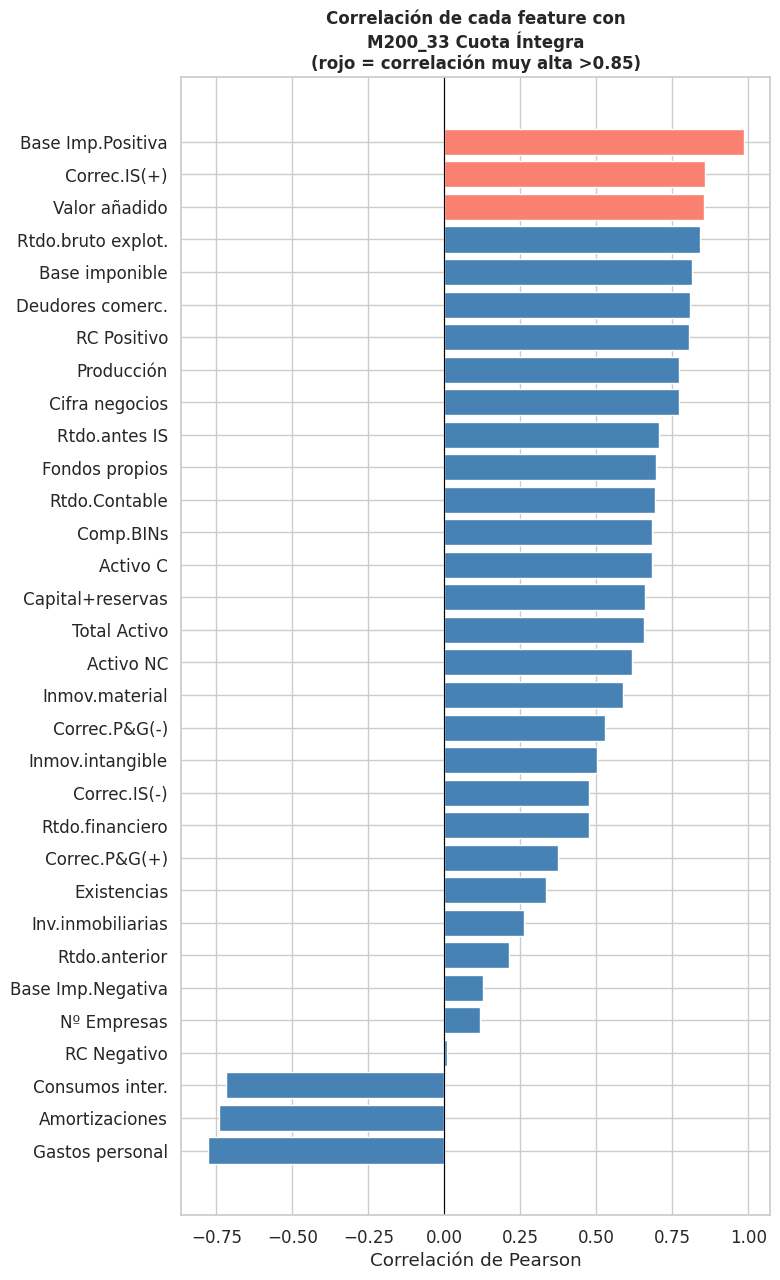

In [63]:
# ══════════════════════════════════════════════════════════════════
# FIG 3 — Correlación de todas las features con el target
# ══════════════════════════════════════════════════════════════════
LEAKAGE = ['M200_34', 'M200_35', 'M200_36', 'M200_37']
fin_cols = [c for c in df.columns if c.startswith('M200_') and c not in LEAKAGE + [TARGET]]

corrs = df[fin_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

colors = ['salmon' if abs(v) > 0.85 else 'steelblue' for v in corrs.values]

NOMBRES = {
    'M200_1':'Nº Empresas', 'M200_2':'Activo NC', 'M200_3':'Inmov.intangible',
    'M200_4':'Inmov.material', 'M200_5':'Inv.inmobiliarias', 'M200_6':'Activo C',
    'M200_7':'Existencias', 'M200_8':'Deudores comerc.', 'M200_9':'Total Activo',
    'M200_10':'Fondos propios', 'M200_11':'Capital+reservas', 'M200_12':'Rtdo.anterior',
    'M200_13':'Cifra negocios', 'M200_14':'Producción', 'M200_15':'Consumos inter.',
    'M200_16':'Valor añadido', 'M200_17':'Gastos personal', 'M200_18':'Rtdo.bruto explot.',
    'M200_19':'Amortizaciones', 'M200_20':'Rtdo.financiero', 'M200_21':'Rtdo.antes IS',
    'M200_22':'Rtdo.Contable', 'M200_23':'RC Positivo', 'M200_24':'RC Negativo',
    'M200_25':'Correc.IS(+)', 'M200_26':'Correc.IS(-)', 'M200_27':'Correc.P&G(+)',
    'M200_28':'Correc.P&G(-)', 'M200_29':'Comp.BINs', 'M200_30':'Base imponible',
    'M200_31':'Base Imp.Positiva', 'M200_32':'Base Imp.Negativa',
}

fig, ax = plt.subplots(figsize=(8, 13))
ax.barh([NOMBRES.get(c, c) for c in corrs.index], corrs.values,
        color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlación de cada feature con\nM200_33 Cuota Íntegra\n(rojo = correlación muy alta >0.85)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

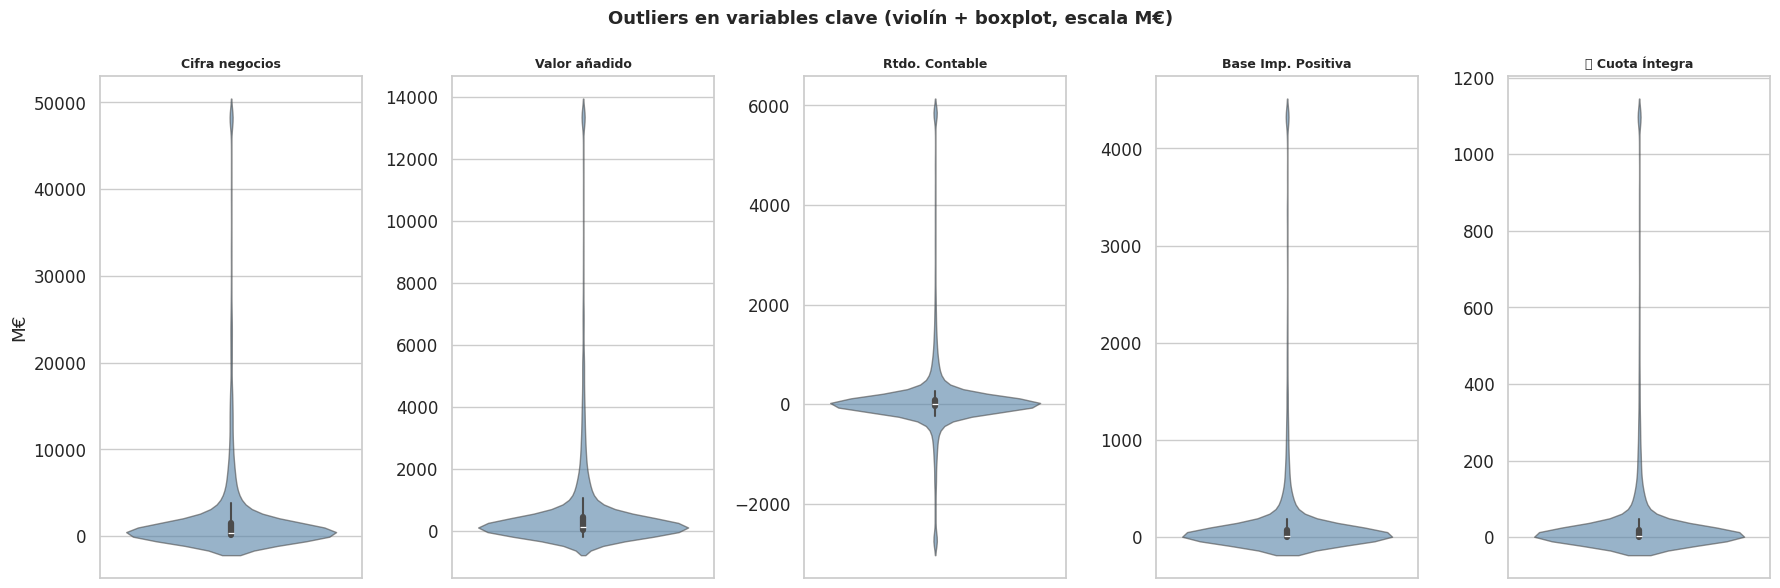

In [64]:
# ══════════════════════════════════════════════════════════════════
# FIG 4 — Outliers de las variables clave
# ══════════════════════════════════════════════════════════════════
VARS = {
    'M200_13': 'Cifra negocios',
    'M200_16': 'Valor añadido',
    'M200_22': 'Rtdo. Contable',
    'M200_31': 'Base Imp. Positiva',
    'M200_33': '⭐ Cuota Íntegra',
}

fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('Outliers en variables clave (violín + boxplot, escala M€)',
             fontsize=13, fontweight='bold')

for ax, (col, nombre) in zip(axes, VARS.items()):
    vals = df[col].dropna() / 1e6
    clip_max = vals.quantile(0.99)
    clip_min = vals.quantile(0.01)
    vals_clip = vals.clip(clip_min, clip_max)

    sns.violinplot(y=vals_clip, ax=ax, color='steelblue', alpha=0.6,
                   inner='box', linewidth=1)
    ax.set_title(nombre, fontsize=9, fontweight='bold')
    ax.set_ylabel('M€' if ax == axes[0] else '')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

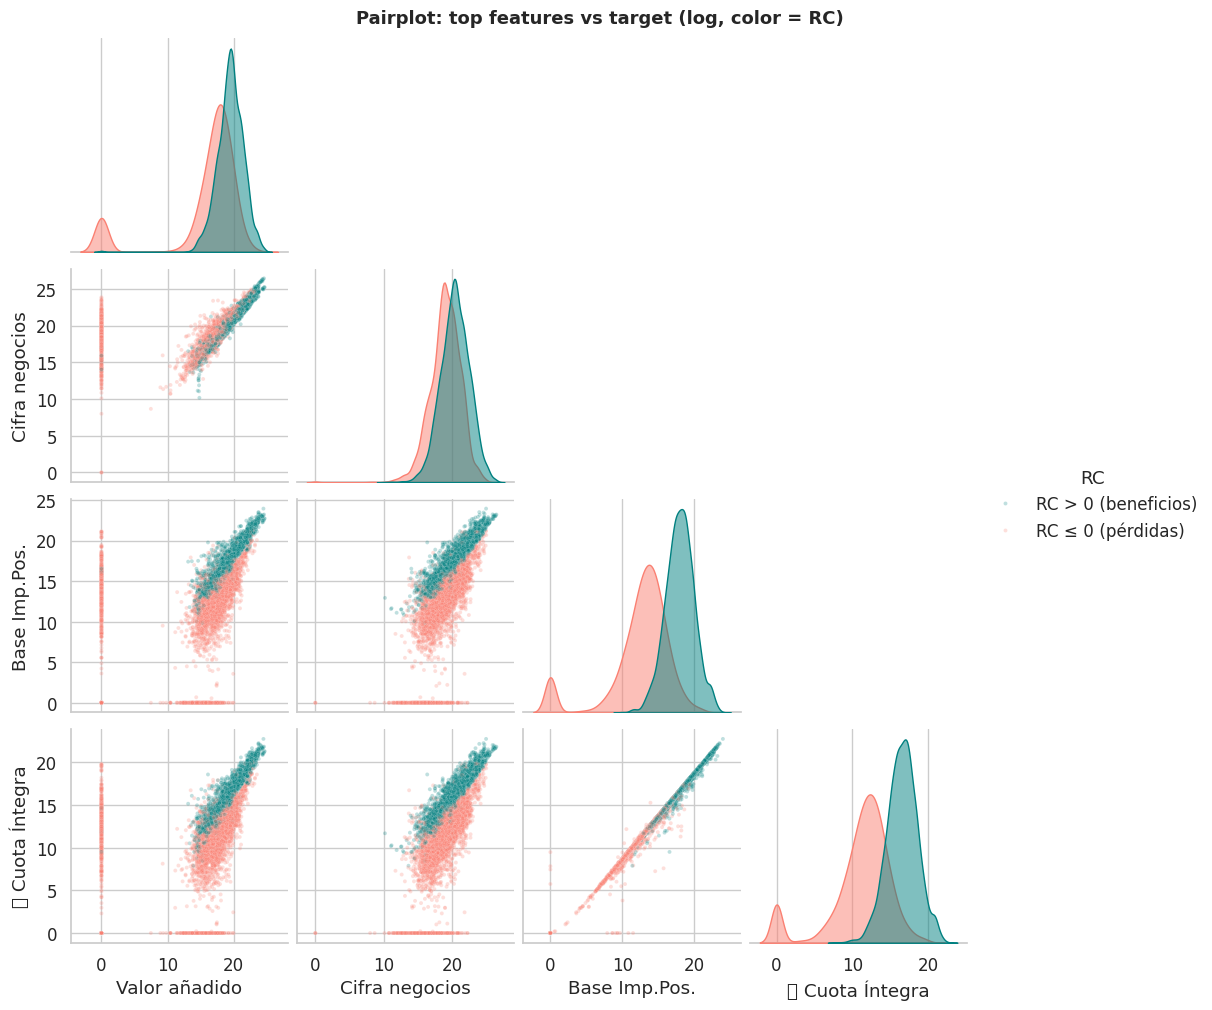

In [59]:
# ══════════════════════════════════════════════════════════════════
# FIG 5 — Pairplot: las 4 mejores features vs target
# ══════════════════════════════════════════════════════════════════
cols_pair = ['M200_16', 'M200_13', 'M200_31', 'M200_33']
nombres_pair = ['Valor añadido', 'Cifra negocios', 'Base Imp.Pos.', '⭐ Cuota Íntegra']

df_pair = np.log1p(df[cols_pair].clip(lower=0))
df_pair.columns = nombres_pair
df_pair['RC'] = df['RC_NM'].values

g = sns.pairplot(df_pair, hue='RC', corner=True,
                 palette={'RC ≤ 0 (pérdidas)': 'salmon',
                          'RC > 0 (beneficios)': 'teal'},
                 plot_kws=dict(alpha=0.25, s=8),
                 diag_kws=dict(fill=True, alpha=0.5))
g.figure.suptitle('Pairplot: top features vs target (log, color = RC)',
                  fontsize=13, fontweight='bold', y=1.01)
plt.show()